In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import joblib

In [2]:
df = pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## About dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### The mean and std for math, reading and writing are almost equal. So data is mostly balanced.

In [5]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

# Create avg score column

In [6]:
df['Avg_scr'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

In [7]:
df['result'] = np.where(df['Avg_scr'] >= 60, 1, 0)
df['result'].value_counts()

result
1    715
0    285
Name: count, dtype: int64

#### It is imbalanced but acceptable for this student prediction.

# Figures to understand dataset more

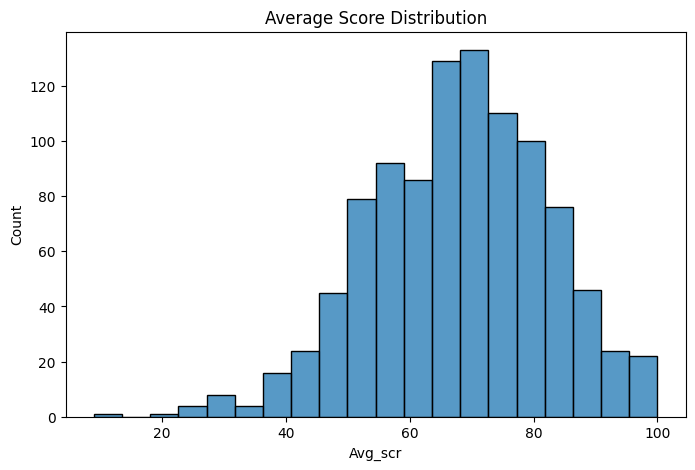

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["Avg_scr"], bins=20)
plt.title("Average Score Distribution")
plt.show()

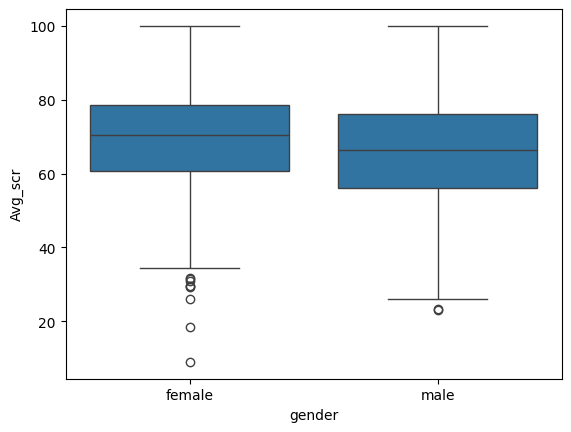

In [9]:
sns.boxplot(
    x="gender",
    y="Avg_scr",
    data=df
)

plt.show()

#### The median for female is around 70 and for male is 65-67. Although both group shows simillar score but female has slightly high median score than male.

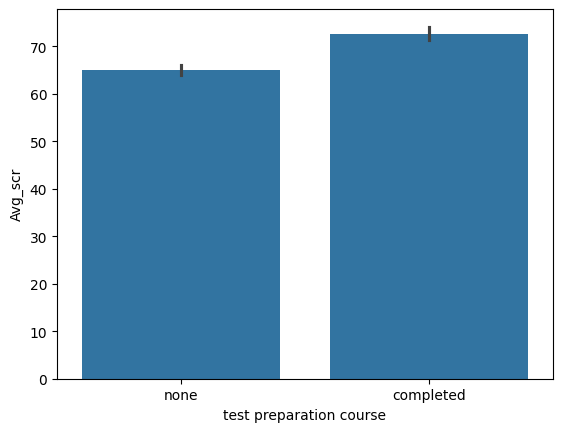

In [10]:
sns.barplot(
    x="test preparation course",
    y="Avg_scr",
    data=df
)

plt.show()

#### Here : without preparation  -> count 65
####        with preparaton -> 72 or 73
#### Difference arounf 7 or 8 marks. Students who completed the test preparation course scored approximately 8 marks higher on average than students who did not complete the course.

# Outliers detection and treating

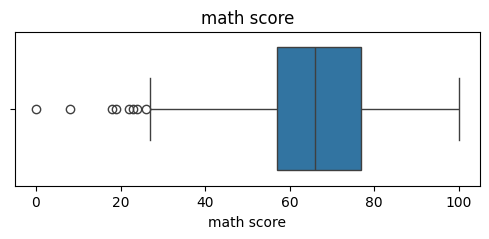

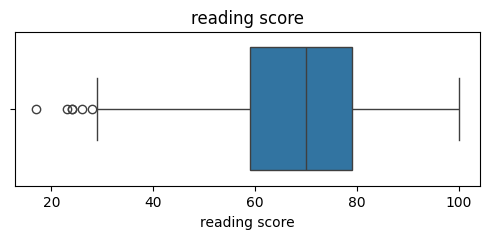

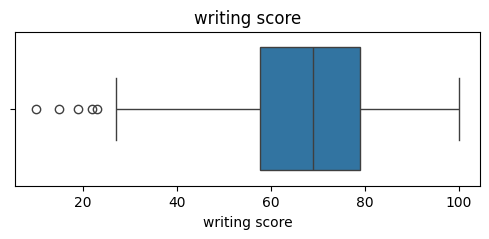

In [11]:
cols = ["math score", "reading score", "writing score"]

for col in cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

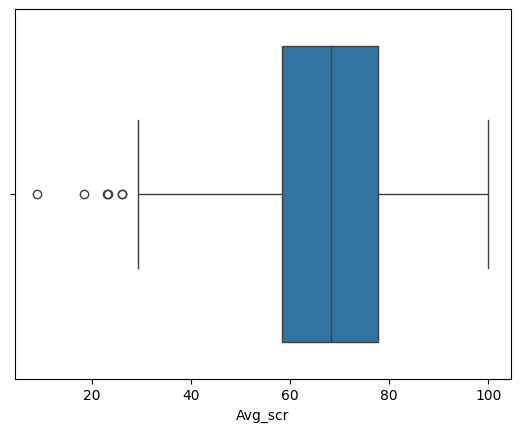

In [12]:
sns.boxplot(x=df["Avg_scr"])
plt.show()

In [13]:
columns = [
    "math score",
    "reading score",
    "writing score"
]

for col in columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {count} outliers")

math score: 8 outliers
reading score: 6 outliers
writing score: 5 outliers


In [14]:
Q1 = df['Avg_scr'].quantile(0.25)
Q3 = df['Avg_scr'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

count = ((df['Avg_scr'] < lower) | (df['Avg_scr'] > upper)).sum()

print(f"{'Avg_scr'}: {count} outliers")


Avg_scr: 6 outliers


#### Though it's only 6 7 outliers so it can be the real student's score. So keep it.

# Correlation Heatmap

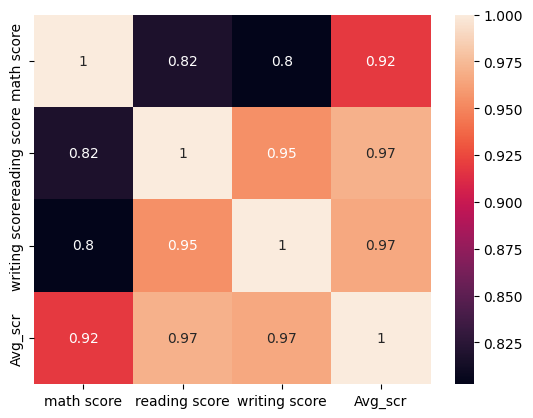

In [15]:
sns.heatmap(
    df[['math score',
        'reading score',
        'writing score',
        'Avg_scr']].corr(),
    annot=True
)
plt.show()

# Encode categorical column

In [16]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    encoders[col] = le

# Train test split

In [32]:
X = df[
    [
       "gender",
        "race/ethnicity",
        "parental level of education",
        "lunch",
        "test preparation course",
        "math score",
        "reading score",
        "writing score"
    ]
]

y = df["result"]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [34]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced',max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(class_weight='balanced',random_state=42),

    "SVM": SVC(class_weight='balanced')
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    score = accuracy_score(y_test, pred)

    results[name] = score

    print(f"{name}: {score:.4f}")

Logistic Regression: 0.9950
Decision Tree: 0.9650
Random Forest: 0.9900
SVM: 0.9550


In [35]:
from sklearn.metrics import classification_report

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    print("\n", name)
    print(classification_report(y_test, pred))


 Logistic Regression
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        57
           1       1.00      0.99      1.00       143

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200


 Decision Tree
              precision    recall  f1-score   support

           0       0.96      0.93      0.95        57
           1       0.97      0.99      0.98       143

    accuracy                           0.97       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.97      0.97       200


 Random Forest
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        57
           1       0.99      0.99      0.99       143

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0

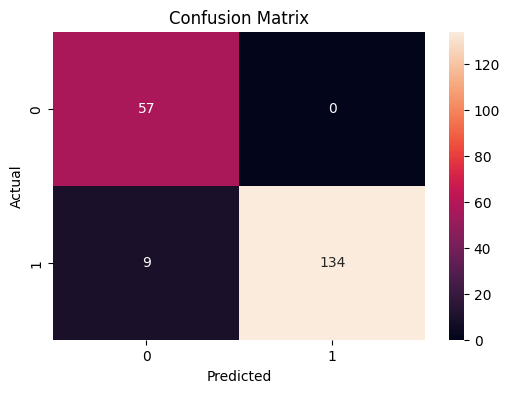

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

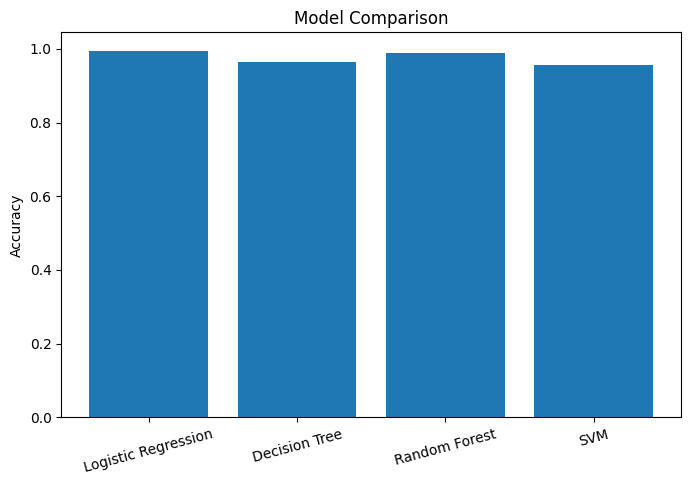

In [37]:
plt.figure(figsize=(8,5))

plt.bar(
    results.keys(),
    results.values()
)

plt.title("Model Comparison")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

In [40]:
best_model = LogisticRegression(max_iter=1000)

best_model.fit(X_train, y_train)

joblib.dump(best_model, "student_model.pkl")

joblib.dump(encoders, "encoders.pkl")

print("Model and encoders saved successfully!")

Model and encoders saved successfully!
